In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


In [2]:
ratings = pd.read_csv("../data/ratings.csv")
movies = pd.read_csv("../data/movies.csv")


In [3]:
print(ratings.head())
ratings.shape
ratings.columns

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')

In [4]:
print(movies.head())
movies.shape
movies.columns

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


Index(['movieId', 'title', 'genres'], dtype='object')

Ratings distribution (bias check)

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


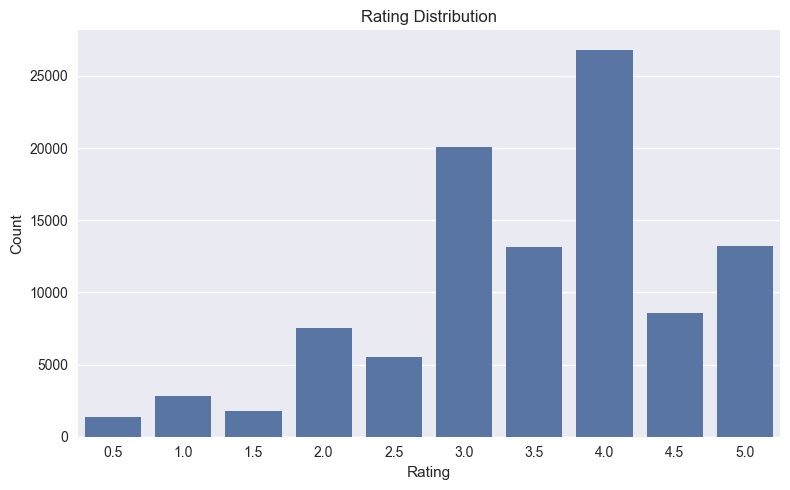

In [5]:
print(ratings['rating'].value_counts().sort_index())
plt.figure(figsize=(8,5))
sns.countplot(x="rating", data=ratings)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../outputs/rating_distribution.png")
plt.show()


User activity analysis

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: rating, dtype: float64


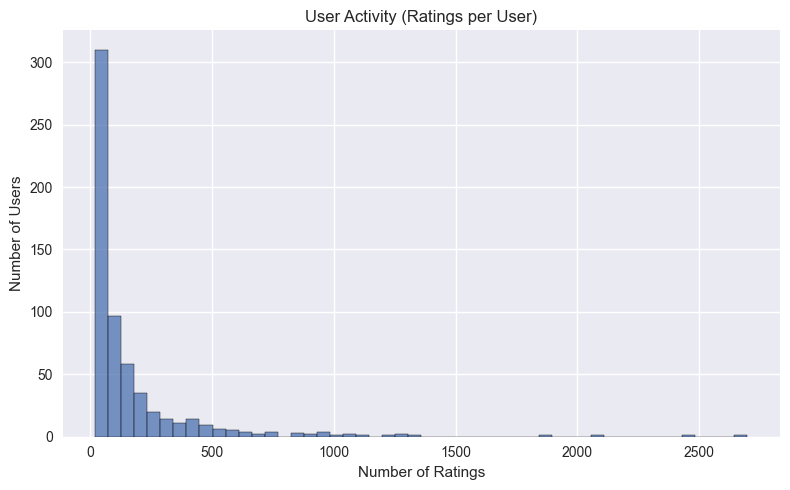

In [6]:
user_activity = ratings.groupby("userId")["rating"].count()
print(user_activity.describe())
plt.figure(figsize=(8,5))
sns.histplot(user_activity, bins=50, kde=False)
plt.title("User Activity (Ratings per User)")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.savefig("../outputs/user_activity.png")
plt.show()


Movie popularity analysis

count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: rating, dtype: float64


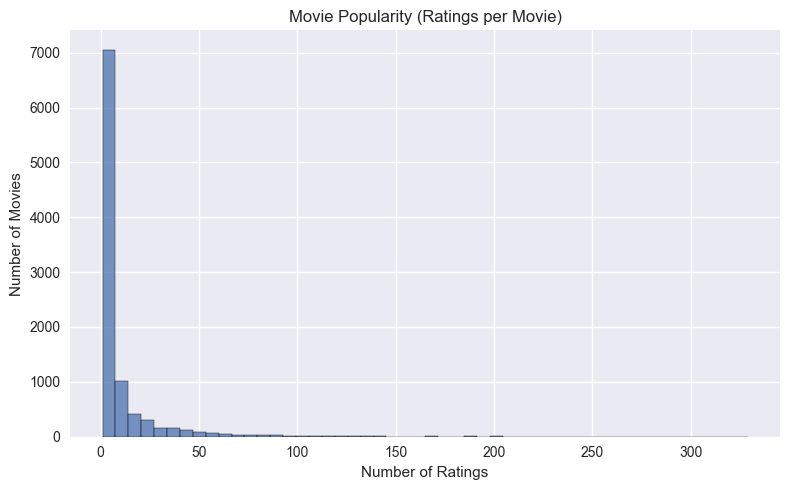

In [7]:
movie_popularity = ratings.groupby("movieId")["rating"].count()
print(movie_popularity.describe())
plt.figure(figsize=(8,5))
sns.histplot(movie_popularity, bins=50, kde=False)
plt.title("Movie Popularity (Ratings per Movie)")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.savefig("../outputs/movie_popularity.png")
plt.show()


Sparsity calculation

In [8]:
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_ratings = len(ratings)

sparsity = 1 - (n_ratings / (n_users * n_movies))
sparsity


0.9830003169443864